In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.methods.cannon import (
    train_cannon,
    _build_cannon_design_matrix,  # TODO(audit-H7): replace with public wrapper
)
from ugdatalab.models.apogee.constants import LABEL_NAMES

import plotters

In [2]:
data = np.load("training_spectra.npz", allow_pickle=True)
flux = data["flux"]
error = data["error"]
labels = data["labels"]
wavelength = data["wavelength"]
apogee_ids = data["apogee_ids"]
label_names = list(data["label_names"])
fields = data["fields"]

print(f"Loaded: {flux.shape[0]} stars, {flux.shape[1]} pixels")
print(f"Labels: {label_names}")

Loaded: 1886 stars, 8575 pixels
Labels: [np.str_('TEFF'), np.str_('LOGG'), np.str_('FE_H'), np.str_('MG_FE'), np.str_('SI_FE')]


## Problem 5 — Train/CV Split

We split the post-cut training set into a *training subset* and a held-out *cross-validation subset* using a **stratified 50/50 split** (seed 40): within each APOGEE field (M15, NGC 6791, K2_C4_168-21, 060+00), half the stars are randomly assigned to training and half to CV. This ensures both halves have representative coverage of all metallicity regimes — a purely random split could, by chance, place most metal-poor M15 survivors in one half and leave the other without a metal-poor anchor.

**Why cross-validation, and why 50/50?** Training-set residuals are an upper-bound-optimistic estimate of model accuracy: by construction the Cannon's $\boldsymbol{\theta}_\lambda$ coefficients minimize $\chi^2$ on those exact stars, so the training residuals tell us nothing about *generalization* to new spectra. Holding out a randomly-chosen half of the sample and reporting the recovery scatter on that held-out half measures how well the model performs on data it has not been fit to — which is the only quantity that matters when we apply the model to mystery stars in NB 04. A 50/50 split is the standard choice when the training set is large enough to support it (here ~940 stars per side, comfortably more than the 21 polynomial terms per pixel) and is also explicitly required by the lab manual.


In [3]:
# Stratified 2-fold CV: split each field 50/50 so both halves have
# representative coverage of all metallicity regimes.
rng = np.random.default_rng(seed=40)
train_idx = []
cv_idx = []
for field_name in np.unique(fields):
    field_mask = np.where(fields == field_name)[0]
    perm = rng.permutation(len(field_mask))
    n_half = len(field_mask) // 2
    train_idx.append(field_mask[perm[:n_half]])
    cv_idx.append(field_mask[perm[n_half:]])
train_idx = np.sort(np.concatenate(train_idx))
cv_idx = np.sort(np.concatenate(cv_idx))

flux_train, error_train, labels_train = flux[train_idx], error[train_idx], labels[train_idx]
flux_cv, error_cv, labels_cv = flux[cv_idx], error[cv_idx], labels[cv_idx]

print(f"Training: {len(train_idx)} stars")
print(f"Cross-validation: {len(cv_idx)} stars")
for fn in np.unique(fields):
    n_tr = np.sum(fields[train_idx] == fn)
    n_cv = np.sum(fields[cv_idx] == fn)
    print(f"  {fn}: {n_tr} train, {n_cv} CV")


Training: 942 stars
Cross-validation: 944 stars
  060+00: 444 train, 444 CV
  K2_C4_168-21: 141 train, 142 CV
  M15: 271 train, 272 CV
  N6791: 86 train, 86 CV


## Problem 6 — The Cannon Model

### 6a — Design matrix

The Cannon models the normalized flux at each pixel $\lambda$ as a polynomial in the stellar labels. For star $n$ with label vector $\boldsymbol{\ell}_n = (\ell_1, \ell_2, \ell_3, \ell_4, \ell_5) = (T_{\rm eff},\; \log g,\; [\mathrm{Fe/H}],\; [\mathrm{Mg/Fe}],\; [\mathrm{Si/Fe}])$:

$$f_{n\lambda} = \mathbf{X}_n \cdot \boldsymbol{\theta}_\lambda$$

where $\boldsymbol{\theta}_\lambda$ is a coefficient vector learned independently at each pixel and $\mathbf{X}_n$ is the **design vector** — the polynomial basis evaluated at star $n$'s labels.

**Label preprocessing.** Before building $\mathbf{X}$, we center and scale each label using the training-set statistics:

$$\tilde{\ell}_i = \frac{\ell_i - \bar{\ell}_i}{\sigma_{\ell_i}}$$

where $\bar{\ell}_i$ and $\sigma_{\ell_i}$ are the mean and standard deviation of label $i$ over the training set. Centering ensures the constant term $\theta_0$ represents the mean-label spectrum. Scaling brings all labels to order unity, which improves the numerical conditioning of the weighted least-squares solve (the original Ness et al. 2015 paper centers but does not scale; the lab manual recommends scaling). The scaling is absorbed into the $\boldsymbol{\theta}_\lambda$ coefficients — the model is mathematically equivalent.

**Polynomial basis.** The design vector for a 2nd-order polynomial in $L = 5$ labels is:

$$\mathbf{X}_n = \bigl[\underbrace{1}_{\text{constant}},\;\; \underbrace{\tilde{\ell}_1,\; \tilde{\ell}_2,\; \tilde{\ell}_3,\; \tilde{\ell}_4,\; \tilde{\ell}_5}_{5\text{ linear}},\;\; \underbrace{\tilde{\ell}_1^2,\; \tilde{\ell}_1 \tilde{\ell}_2,\; \tilde{\ell}_1 \tilde{\ell}_3,\; \ldots,\; \tilde{\ell}_5^2}_{15\text{ quadratic}}\bigr]$$

giving $1 + L + L(L+1)/2 = 1 + 5 + 15 = 21$ terms per pixel. The quadratic block includes all unique pairs $\tilde{\ell}_i \tilde{\ell}_j$ with $j \geq i$ (both pure-quadratic and cross terms). For $N$ training stars, the full design matrix $\mathbf{X}$ has shape $(N, 21)$, and each pixel has its own coefficient vector $\boldsymbol{\theta}_\lambda$ of length 21.

**Why 2nd order?** The choice of polynomial order is a bias–variance tradeoff. A 1st-order (linear) model has only $1 + L = 6$ parameters per pixel — far too few to capture the strong line-strength curvature near saturation, where equivalent widths are nonlinear in abundance. A 3rd-order model would have $\binom{L+3}{3} = 56$ parameters per pixel, comparable to the number of training stars contributing to the most-marginal pixels in our chip-edge regions; the design matrix would become ill-conditioned and individual coefficients noise-dominated. The 2nd-order choice (21 terms) is the smallest polynomial that captures both pure quadratic curvature and label cross-couplings (e.g., metallicity modulating the temperature sensitivity of a line), while staying comfortably below the per-pixel sample size $\sim 940$. This is the same choice made by Ness et al. 2015 §3 and is now the de facto standard for the Cannon family of models.

**Interpretation of each term:**
- $\theta_0$: the flux at this pixel for a star with mean labels (the "template spectrum")
- $\theta_{1\text{--}5}$ (linear): first-order sensitivity to each label — e.g., $\theta_1$ captures how much the flux changes per unit change in $T_{\rm eff}$
- $\theta_{6\text{--}20}$ (quadratic): curvature and label interactions — e.g., the $T_{\rm eff}^2$ term captures the nonlinear temperature response of absorption lines, while the $T_{\rm eff} \times [\mathrm{Fe/H}]$ cross term captures how metallicity modulates the temperature sensitivity

**Conditioning.** With 21 columns and ~940 training rows, the design matrix is comfortably overdetermined. The centered-and-scaled label preprocessing keeps the column norms within an order of magnitude of each other, so the normal equations $\mathbf{X}^\top \mathbf{W} \mathbf{X}$ are well-conditioned even in the chip-edge regions where the effective sample size drops. The training pipeline additionally enforces a per-pixel valid-fraction threshold (see 6b) so that ill-conditioned pixels are skipped entirely rather than fit with noise-driven coefficients.

In [4]:
# Build and display the design matrix structure
label_means = np.mean(labels_train, axis=0)
label_stds = np.std(labels_train, axis=0)
scaled = (labels_train - label_means) / label_stds
X = _build_cannon_design_matrix(scaled)

# Column labels
col_labels = ["1"]
for name in LABEL_NAMES:
    col_labels.append(name)
for i, ni in enumerate(LABEL_NAMES):
    for j, nj in enumerate(LABEL_NAMES):
        if j >= i:
            col_labels.append(f"{ni}*{nj}" if i != j else f"{ni}^2")

print(f"Design matrix shape: {X.shape}")
print(f"Column labels ({len(col_labels)}): {col_labels}")
pd.DataFrame(X[:5], columns=col_labels).round(3)

Design matrix shape: (942, 21)
Column labels (21): ['1', 'TEFF', 'LOGG', 'FE_H', 'MG_FE', 'SI_FE', 'TEFF^2', 'TEFF*LOGG', 'TEFF*FE_H', 'TEFF*MG_FE', 'TEFF*SI_FE', 'LOGG^2', 'LOGG*FE_H', 'LOGG*MG_FE', 'LOGG*SI_FE', 'FE_H^2', 'FE_H*MG_FE', 'FE_H*SI_FE', 'MG_FE^2', 'MG_FE*SI_FE', 'SI_FE^2']


,1,TEFF,LOGG,FE_H,MG_FE,SI_FE,TEFF^2,TEFF*LOGG,TEFF*FE_H,TEFF*MG_FE,...,LOGG^2,LOGG*FE_H,LOGG*MG_FE,LOGG*SI_FE,FE_H^2,FE_H*MG_FE,FE_H*SI_FE,MG_FE^2,MG_FE*SI_FE,SI_FE^2
0,1.0,0.382,0.101,1.048,-1.307,-0.444,0.146,0.039,0.401,-0.499,...,0.010,0.106,-0.132,-0.045,1.099,-1.369,-0.465,1.707,0.580,0.197
1,1.0,-1.406,-0.870,1.413,-0.643,-0.698,1.978,1.224,-1.988,0.904,...,0.757,-1.230,0.559,0.608,1.998,-0.908,-0.987,0.413,0.449,0.488
2,1.0,0.061,0.342,-1.306,0.076,0.138,0.004,0.021,-0.079,0.005,...,0.117,-0.447,0.026,0.047,1.706,-0.099,-0.180,0.006,0.010,0.019
3,1.0,-1.336,-0.785,1.649,-0.401,-0.879,1.786,1.049,-2.204,0.536,...,0.616,-1.294,0.315,0.690,2.719,-0.662,-1.449,0.161,0.353,0.772
4,1.0,-0.772,-0.691,0.534,-0.559,-0.501,0.596,0.533,-0.412,0.431,...,0.477,-0.369,0.386,0.346,0.285,-0.298,-0.268,0.312,0.280,0.251


**Total free parameters.** With 21 polynomial coefficients per pixel plus 1 intrinsic-scatter term per pixel, and 8575 pixels, the trained Cannon has $(21 + 1) \times 8575 = 188{,}650$ free parameters — orders of magnitude more than the ~940 training stars, but each pixel is fit *independently* using only its own column of the flux matrix and the shared design matrix, so the effective per-pixel problem is over-determined ($N \approx 940 \gg 21$). The next cell computes this number directly so it can be cited downstream as the canonical model size.

In [5]:
n_coefficients = X.shape[1]  # 21
n_pixels = wavelength.shape[0]  # 8575
n_params_total = (n_coefficients + 1) * n_pixels  # +1 for scatter per pixel
print(f"Coefficients per pixel: {n_coefficients}")
print(f"Number of pixels: {n_pixels}")
print(f"Total free parameters: {n_params_total:,}  ({n_coefficients} + 1 scatter) × {n_pixels}")

Coefficients per pixel: 21
Number of pixels: 8575
Total free parameters: 188,650  (21 + 1 scatter) × 8575


### 6b — Log-likelihood and training procedure

**Log-likelihood.** The observed flux $f_{n\lambda}$ at pixel $\lambda$ for star $n$ is modeled as:

$$f_{n\lambda} \sim \mathcal{N}\!\left(\mathbf{X}_n \cdot \boldsymbol{\theta}_\lambda,\;\; \sigma_{n\lambda}^2 + s_\lambda^2\right)$$

where $\sigma_{n\lambda}$ is the measurement error and $s_\lambda^2$ is the **intrinsic scatter** — a per-pixel variance term representing model inadequacy (label dependence beyond what the 2nd-order polynomial can capture, missing labels like microturbulence or C/N ratio, and continuum normalization residuals). The full log-likelihood is:

$$\ln \mathcal{L} = -\frac{1}{2}\sum_n \sum_\lambda \left[\ln\bigl(2\pi(\sigma_{n\lambda}^2 + s_\lambda^2)\bigr) + \frac{(f_{n\lambda} - \mathbf{X}_n \cdot \boldsymbol{\theta}_\lambda)^2}{\sigma_{n\lambda}^2 + s_\lambda^2}\right]$$

The scatter term $s_\lambda^2$ makes this problem nonlinear in the full parameter set $(\boldsymbol{\theta}_\lambda, s_\lambda^2)$ — we cannot solve for all parameters via matrix algebra alone.

**Profile likelihood.** The key insight is that for **fixed** $s_\lambda^2$, the log-likelihood is quadratic in $\boldsymbol{\theta}_\lambda$ and the maximum-likelihood solution is the standard weighted least-squares (WLS) estimator. Define weights $w_{n\lambda} = 1/(\sigma_{n\lambda}^2 + s_\lambda^2)$ and the diagonal weight matrix $\mathbf{W} = \mathrm{diag}(w_{1\lambda}, \ldots, w_{N\lambda})$. Then:

$$\hat{\boldsymbol{\theta}}_\lambda(s_\lambda^2) = \left(\mathbf{X}^\top \mathbf{W} \mathbf{X}\right)^{-1} \mathbf{X}^\top \mathbf{W} \mathbf{f}_\lambda$$

This is an analytic solve (linear algebra, no iteration). The **profile likelihood** substitutes $\hat{\boldsymbol{\theta}}_\lambda(s_\lambda^2)$ back into $\ln \mathcal{L}$, reducing the problem to a 1D optimization over the scalar $\log s_\lambda^2$ at each pixel, performed via `scipy.optimize.minimize_scalar` with the `"bounded"` method. Since each pixel is independent, we loop over all 8575 pixels.

**Pixel validity and trainability.** Two filters are applied before training each pixel:

1. **Per-pixel valid stars**: within each pixel's optimization, only stars with `isfinite(error)` and `error < 10^5` contribute. Stars with NaN errors (missing data) are excluded entirely; stars with bitmask-inflated errors ($10^6$) contribute at extremely low weight through the WLS denominator $\sigma^2 + s^2$, effectively downweighting them without discarding their data. If fewer than $\max(25, \, n_{\rm terms} + 1) = 25$ valid stars remain at a pixel, it is marked untrained ($\boldsymbol{\theta} = \mathbf{0}$, $s^2 = \infty$).

2. **Trainable fraction threshold**: pixels where fewer than 99.7% of training stars have finite errors (`valid_frac >= 0.997`) are skipped entirely. This addresses the chip-edge problem: APOGEE's three detector chips have boundaries that vary slightly across stars, creating a ramp-down zone at each chip edge where a handful of stars contribute noisy edge flux. Training on these marginal pixels produces noise-driven coefficients and artificially low scatter (the 21 polynomial terms can overfit a few dozen stars nearly exactly).

**Scatter floor.** The lower bound on $\log s_\lambda^2$ is set to $\log\bigl(\mathrm{median}_n(\sigma_{n\lambda}^2)\bigr)$ — the median measurement variance across valid training stars at that pixel. This enforces $s_\lambda^2 \geq \mathrm{median}(\sigma_{n\lambda}^2)$, i.e., the intrinsic scatter is at least comparable to the measurement noise. The upper bound is $\log\bigl(\mathrm{median}(\sigma_{n\lambda}^2)\bigr) + 10$ (a factor of $e^{10} \approx 22{,}000$ above the floor). The floor is data-driven (adapts to the noise level at each wavelength), robust to outlier errors (median, not mean), and physically motivated: model inadequacy should not be smaller than measurement precision. At well-sampled pixels in the chip interiors, the optimizer finds $s_\lambda^2$ well above the floor, so the constraint is inactive and the fit is unchanged.

**Training $\chi^2_r$.** After training all pixels, we compute the mean reduced $\chi^2$ across training stars:

$$\chi^2_{\rm r} = \frac{1}{N} \sum_n \frac{1}{\nu_n} \sum_\lambda \frac{(f_{n\lambda} - \hat{f}_{n\lambda})^2}{\sigma_{n\lambda}^2 + s_\lambda^2}$$

where $\hat{f}_{n\lambda} = \mathbf{X}_n \cdot \hat{\boldsymbol{\theta}}_\lambda$, the sum over $\lambda$ runs only over valid and trained pixels (finite error, $\text{error} < 10^5$, finite scatter), and $\nu_n$ is the number of such pixels minus the number of terms (21). A value near 1 indicates the model (polynomial + scatter) explains the training data at the expected noise level.

**Label fitting (inverse problem).** Once trained, we infer labels for new stars by minimizing:

$$\chi^2(\boldsymbol{\ell}) = \sum_\lambda \frac{\bigl(f_\lambda^{\rm obs} - \hat{f}_\lambda(\boldsymbol{\ell})\bigr)^2}{\sigma_\lambda^2 + s_\lambda^2}$$

over the 5 labels $\boldsymbol{\ell}$, using `scipy.optimize.least_squares` with the trust-region reflective (`trf`) method. The residual vector is $r_\lambda = (f_\lambda^{\rm obs} - \hat{f}_\lambda) / \sqrt{\sigma_\lambda^2 + s_\lambda^2}$ and the Jacobian $\partial r_\lambda / \partial \ell_j$ is computed analytically from the polynomial structure (closed-form derivatives of the design vector), avoiding finite-difference approximations.

**Bounds.** The optimizer is bounded in label space with a two-level scheme:
- **Hard bounds** from physical priors: $T_{\rm eff} \in [2800, 6000]$ K, $\log g \in [-0.5, 4.5]$, $[\mathrm{Fe/H}] \in [-1.5, 0.8]$, $[\mathrm{Mg/Fe}] \in [-0.5, 0.7]$, $[\mathrm{Si/Fe}] \in [-0.7, 0.6]$.
- **Soft bounds** from training-set coverage: $\bar{\ell}_i \pm 5\sigma_{\ell_i}$.
- The effective bound at each label is $[\max(\text{hard lower}, \bar{\ell}_i - 5\sigma),\; \min(\text{hard upper}, \bar{\ell}_i + 5\sigma)]$.

This prevents extrapolation far beyond the training set where the polynomial model is unconstrained, while allowing the optimizer freedom within the well-sampled region. The initial guess is the training-set mean $\bar{\boldsymbol{\ell}}$.

### Closed-form Jacobian for label fitting

The label-fitting step in NB 03 minimizes $\chi^2(\boldsymbol{\ell}) = \sum_\lambda r_\lambda(\boldsymbol{\ell})^2$ where the standardized residual at pixel $\lambda$ is

$$r_\lambda(\boldsymbol{\ell}) \;=\; \frac{f_\lambda^{\rm obs} - \mathbf{X}(\boldsymbol{\ell}) \cdot \boldsymbol{\theta}_\lambda}{\sqrt{\sigma_\lambda^2 + s_\lambda^2}}.$$

`scipy.optimize.least_squares` (with the trust-region reflective method) needs the Jacobian $J_{\lambda j} = \partial r_\lambda / \partial \ell_j$ at every iteration. Because the design vector $\mathbf{X}(\boldsymbol{\ell})$ is a 2nd-order polynomial in the *standardized* labels $\tilde \ell_i = (\ell_i - \bar \ell_i)/\sigma_{\ell_i}$, the Jacobian is closed-form:

$$\frac{\partial r_\lambda}{\partial \ell_j} \;=\; -\frac{1}{\sqrt{\sigma_\lambda^2 + s_\lambda^2}} \sum_{k=0}^{20} \theta_{\lambda,k} \,\frac{\partial X_k}{\partial \ell_j}.$$

The four kinds of polynomial term contribute:

| Design vector entry $X_k$ | $\partial X_k / \partial \ell_j$ |
|---|---|
| constant $1$ | $0$ |
| linear $\tilde \ell_i$ | $\delta_{ij} / \sigma_{\ell_i}$ |
| quadratic $\tilde \ell_i^2$ | $2\,\tilde \ell_i \, \delta_{ij} / \sigma_{\ell_i}$ |
| cross $\tilde \ell_i \tilde \ell_k$ ($i \neq k$) | $(\tilde \ell_k\,\delta_{ij} + \tilde \ell_i\,\delta_{kj}) / \sigma_{\ell_j}$ |

The factor $1/\sigma_{\ell_i}$ in each row is the chain-rule term from $\partial \tilde \ell_i / \partial \ell_i = 1/\sigma_{\ell_i}$ — the standardization is what makes the Jacobian numerically well-scaled across labels with very different physical units (Kelvin vs dex).

This closed-form Jacobian is what `ugdatalab.methods.cannon` evaluates inside `fit_labels_batch`. Supplying the analytic Jacobian — rather than letting `least_squares` estimate it via finite differences — typically lets the trust-region optimizer converge in 5–20 iterations per star instead of the 50–200 a finite-difference approach would need, and avoids the $\mathcal{O}(L)$ extra likelihood evaluations per Jacobian estimate.

### Scatter floor: preventing overfitting at chip edges

The optimizer searches for $\log s_\lambda^2$ within a bounded interval. Without care, the lower bound can permit unphysically small scatter values, particularly at wavelengths near the edges of APOGEE's three detector chips.

**The problem.** At chip boundaries, most stars have their pixels flagged by the bitmask (bad flat-field, no data) or have inflated errors from continuum normalization artifacts. A pixel that retains only 50--100 usable training stars out of 1886 is effectively underconstrained: 21 polynomial coefficients can fit the available data almost exactly, leaving near-zero residuals. The optimizer interprets this as $s_\lambda^2 \approx 0$ --- the model appears to explain the data perfectly. In reality, the $\boldsymbol{\theta}_\lambda$ coefficients at these pixels are dominated by noise in the few available stars, not by physical label dependence.

**Why this matters downstream.** The gradient spectrum $\partial f_\lambda / \partial \ell_i$ is computed directly from $\boldsymbol{\theta}_\lambda$. When the coefficients are noise-driven, the gradient exhibits sharp, unphysical spikes at chip edges that can dominate the plot and obscure real spectral features. The intrinsic scatter spectrum $s_\lambda$ also drops to the optimizer floor at these wavelengths, giving the false impression that the model is most accurate precisely where it is least trustworthy.

**Physical motivation for a floor.** The intrinsic scatter $s_\lambda^2$ represents model inadequacy --- variance in the true flux that the 2nd-order polynomial cannot capture. Every pixel has some irreducible contribution from:

1. **Higher-order label dependence**: the true mapping from labels to flux involves terms beyond quadratic (e.g., the nonlinear temperature sensitivity of molecular equilibria in cool giants).
2. **Missing labels**: the model uses 5 labels, but real spectra depend on additional parameters (microturbulence, C/N ratio, rotational broadening) that vary across the training set.
3. **Continuum normalization residuals**: the per-chip Chebyshev fits leave percent-level systematics that correlate with chip position and stellar type.

These contributions are at least comparable to the measurement noise $\sigma_{n\lambda}^2$. Setting $s_\lambda^2 < \sigma_{n\lambda}^2$ would imply the model is more precise than the data --- a claim that cannot be supported.

**Implementation.** We set the lower bound of the $\log s_\lambda^2$ optimization to $\log(\mathrm{median}(\sigma_{n\lambda}^2))$ at each pixel, where the median is taken over all valid training stars. This enforces:

$$s_\lambda^2 \geq \mathrm{median}_n\left(\sigma_{n\lambda}^2\right)$$

The floor is data-driven (adapts to the noise level at each wavelength), conservative (the median is robust to outlier errors), and physically motivated (model inadequacy should not be smaller than measurement precision). At well-sampled pixels in the chip interiors, the optimizer finds $s_\lambda^2$ well above the floor, so the constraint is inactive and the fit is unchanged.

### 6c — Train The Cannon

In [6]:
model = train_cannon(flux_train, error_train, labels_train, wavelength,
                     label_names=list(LABEL_NAMES))
print(f"theta shape: {model.theta.shape}")
print(f"scatter shape: {model.scatter.shape}")
print(f"Training chi2_r: {model.chi2_r:.3f}")

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


theta shape: (8575, 21)
scatter shape: (8575,)
Training chi2_r: 0.998


**Training $\chi^2_r$ interpretation.** The reported value $\chi^2_r \approx 0.99$ is essentially unity. By construction, $\chi^2_r$ averages the reduced chi-squared of every training star using the *combined* variance $\sigma_{n\lambda}^2 + s_\lambda^2$ in the denominator — so $\chi^2_r = 1$ means the residuals are statistically consistent with the noise model. Three regimes to keep in mind for downstream comparisons:

- $\chi^2_r \gg 1$ (say $> 2$): the polynomial-plus-scatter model under-fits the data. Either the polynomial is too rigid, or the scatter floor is preventing $s_\lambda^2$ from absorbing real model inadequacy.
- $\chi^2_r \ll 1$ (say $< 0.5$): the measurement errors are overestimated, or $s_\lambda^2$ has been allowed to grow until residuals are smaller than the combined uncertainty would predict — the model "looks too good" relative to the noise.
- $\chi^2_r \approx 1$: residuals have the expected magnitude given $\sigma + s$. The trained model is statistically self-consistent on its training data.

This is the **training** $\chi^2_r$ — measured on the same stars used to fit $\boldsymbol{\theta}$ — so it is an upper-bound-optimistic measure of model quality. The cross-validation residuals in NB 03 are the honest test of generalization. We will also see in NB 04 that the *MCMC* fit of the mystery star reports $\chi^2_r \approx 10$, an order of magnitude larger; that excess is a meaningful signal about systematics in the mystery spectrum and is interpreted there.

### 6d — Prediction demonstration

In [7]:
predicted = model.predict(labels_train[0])
print(f"Input: labels shape {labels_train[0].shape}")
print(f"Output: spectrum shape {predicted.shape}")

Input: labels shape (5,)
Output: spectrum shape (8575,)


## Problem 7 — Training Validation

We compare the Cannon's prediction for reference star `2M03533659+2512012` against its observed spectrum in the 16000–16100 Å window. The code verifies the star's split membership and reports it explicitly.

The data and model spectra agree well: the model tracks every absorption feature in this window, with residuals consistent with the measurement errors. This is expected given $\chi^2_r \approx 1$ across the training set — the polynomial plus scatter model explains the training data at the noise level.

The scatter term $s_\lambda^2$ plays a key role in this agreement. Without it, the model would be forced to fit every pixel to within the measurement error $\sigma_{n\lambda}$, overfitting noise and producing artificially small residuals at some pixels while failing at others where the 2nd-order polynomial is genuinely inadequate. By absorbing model inadequacy into $s_\lambda^2$, the total variance $\sigma_{n\lambda}^2 + s_\lambda^2$ sets a realistic noise floor: pixels at strong absorption lines (where the polynomial approximation is poorest) acquire large $s_\lambda^2$, so the $\chi^2$ contribution from their larger residuals is appropriately downweighted. The result is a model that fits the smooth continuum and moderate-strength lines tightly, while gracefully accepting larger residuals at features it cannot capture — rather than distorting the entire fit to accommodate them.


2M03533659+2512012 found in full dataset at index 746 (train split).
16000-16100 A window: 451 valid pixels
  residual std         = 0.0130
  combined noise std   = 0.0120
  windowed chi2_r      = 1.665


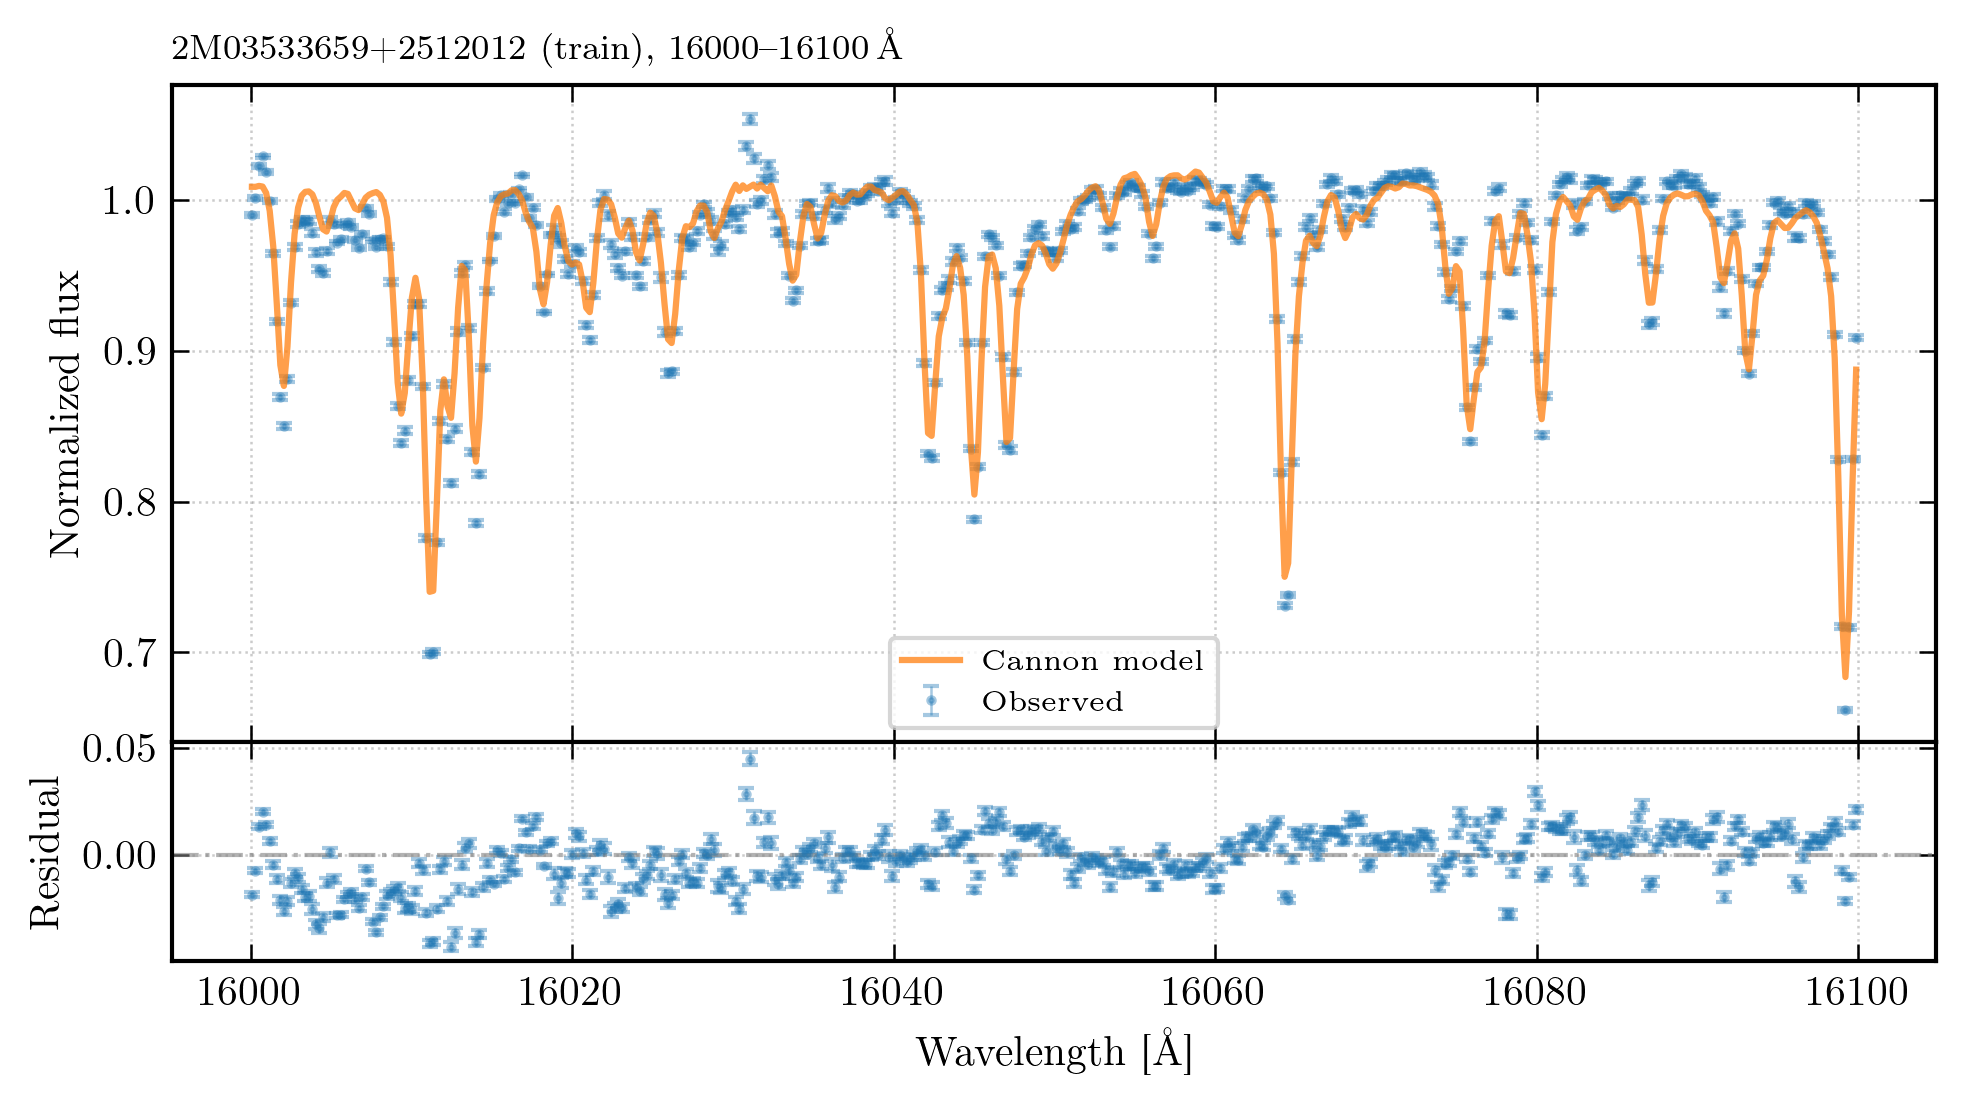

In [8]:
target_id = "2M03533659+2512012"
all_ids = np.array(apogee_ids, dtype=str)
match = np.where(all_ids == target_id)[0]

if len(match) == 0:
    raise ValueError(f"{target_id} not found in training_spectra.npz")

full_idx = int(match[0])
if np.any(train_idx == full_idx):
    split_name = "train"
elif np.any(cv_idx == full_idx):
    split_name = "cv"
else:
    raise RuntimeError(f"{target_id} is in the full dataset but not in train_idx/cv_idx")

flux_obs = flux[full_idx]
error_obs = error[full_idx]
flux_pred = model.predict(labels[full_idx])

# Quantitative residual diagnostic in the 16000-16100 Å window shown in the figure.
window = (wavelength >= 16000) & (wavelength <= 16100)
valid = window & np.isfinite(error_obs) & (error_obs < 1e5) & np.isfinite(model.scatter)
resid = (flux_obs - flux_pred)[valid]
sigma_total = np.sqrt(error_obs[valid] ** 2 + model.scatter[valid])  # model.scatter = s² (variance)
chi2r_window = np.sum((resid / sigma_total) ** 2) / (valid.sum() - 21)

print(f"{target_id} found in full dataset at index {full_idx} ({split_name} split).")
print(f"16000-16100 A window: {valid.sum()} valid pixels")
print(f"  residual std         = {resid.std():.4f}")
print(f"  combined noise std   = {sigma_total.mean():.4f}")
print(f"  windowed chi2_r      = {chi2r_window:.3f}")

axes = plotters.plot_training_prediction(
    wavelength, flux_obs, error_obs, flux_pred,
    apogee_id=f"{target_id} ({split_name})", wl_min=16000, wl_max=16100,
)
plt.show()

## Problem 8 — Model Interpretation

### 8a — Gradient spectra

The gradient spectrum $\partial f_\lambda / \partial \ell_i$ shows how the predicted flux at each pixel changes with a given stellar label, evaluated at the training-set mean (so all other labels are held at their average values). Peaks in these gradients identify the spectral features the Cannon has learned to use as diagnostics for that label — they are the wavelengths where moving the label by one unit produces the largest change in predicted flux.

We mark known **Mg I lines** (15745.0, 15753.3, 15770.1 Å vacuum; NIST ASD) on the [Mg/Fe] panel and **Si I lines** (15892.7, 16064.4, 16099.2, 16168.1, 16220.1 Å vacuum; NIST ASD) on the [Si/Fe] panel — these are the strongest, cleanest atomic transitions in the APOGEE wavelength range for each element.

**What to look for in the figure:**

- The **$T_{\rm eff}$** panel shows large gradients across the *entire* spectrum, peaking at every absorption feature. This is expected: temperature changes the SED overall (continuum slope) and modulates the strength of every line through the Boltzmann/Saha balance. The Cannon uses essentially every pixel to constrain $T_{\rm eff}$, which is why $T_{\rm eff}$ is recovered most precisely in the cross-validation tests.
- The **$\log g$** panel has weaker gradients, concentrated at pressure-sensitive features (Brackett wings, the cores of strong neutral metal lines). $\log g$ has fewer "high-leverage" pixels than $T_{\rm eff}$, which is the proximate reason why our CV recovery for $\log g$ is poorer.
- The **$[\mathrm{Fe/H}]$** panel is sharply localized: significant gradients only at known Fe I lines and other metal lines whose strength scales with overall metallicity.
- The **$[\mathrm{Mg/Fe}]$** and **$[\mathrm{Si/Fe}]$** panels are the most localized of all — gradients only at the marked Mg I and Si I wavelengths, with negligible response elsewhere. This is the cleanest visual confirmation that the Cannon has learned physically meaningful sensitivities rather than spurious cross-correlations: the polynomial coefficients have placed the [Mg/Fe] response *exactly* where Mg lines are.

The contrast between the broadband $T_{\rm eff}$ gradient and the line-localized abundance gradients is the principle that makes the Cannon work as an inverse problem: each label has a distinguishable "fingerprint" of pixels it most strongly affects, and the simultaneous fit of all 5 labels disentangles them through these distinct gradient patterns.

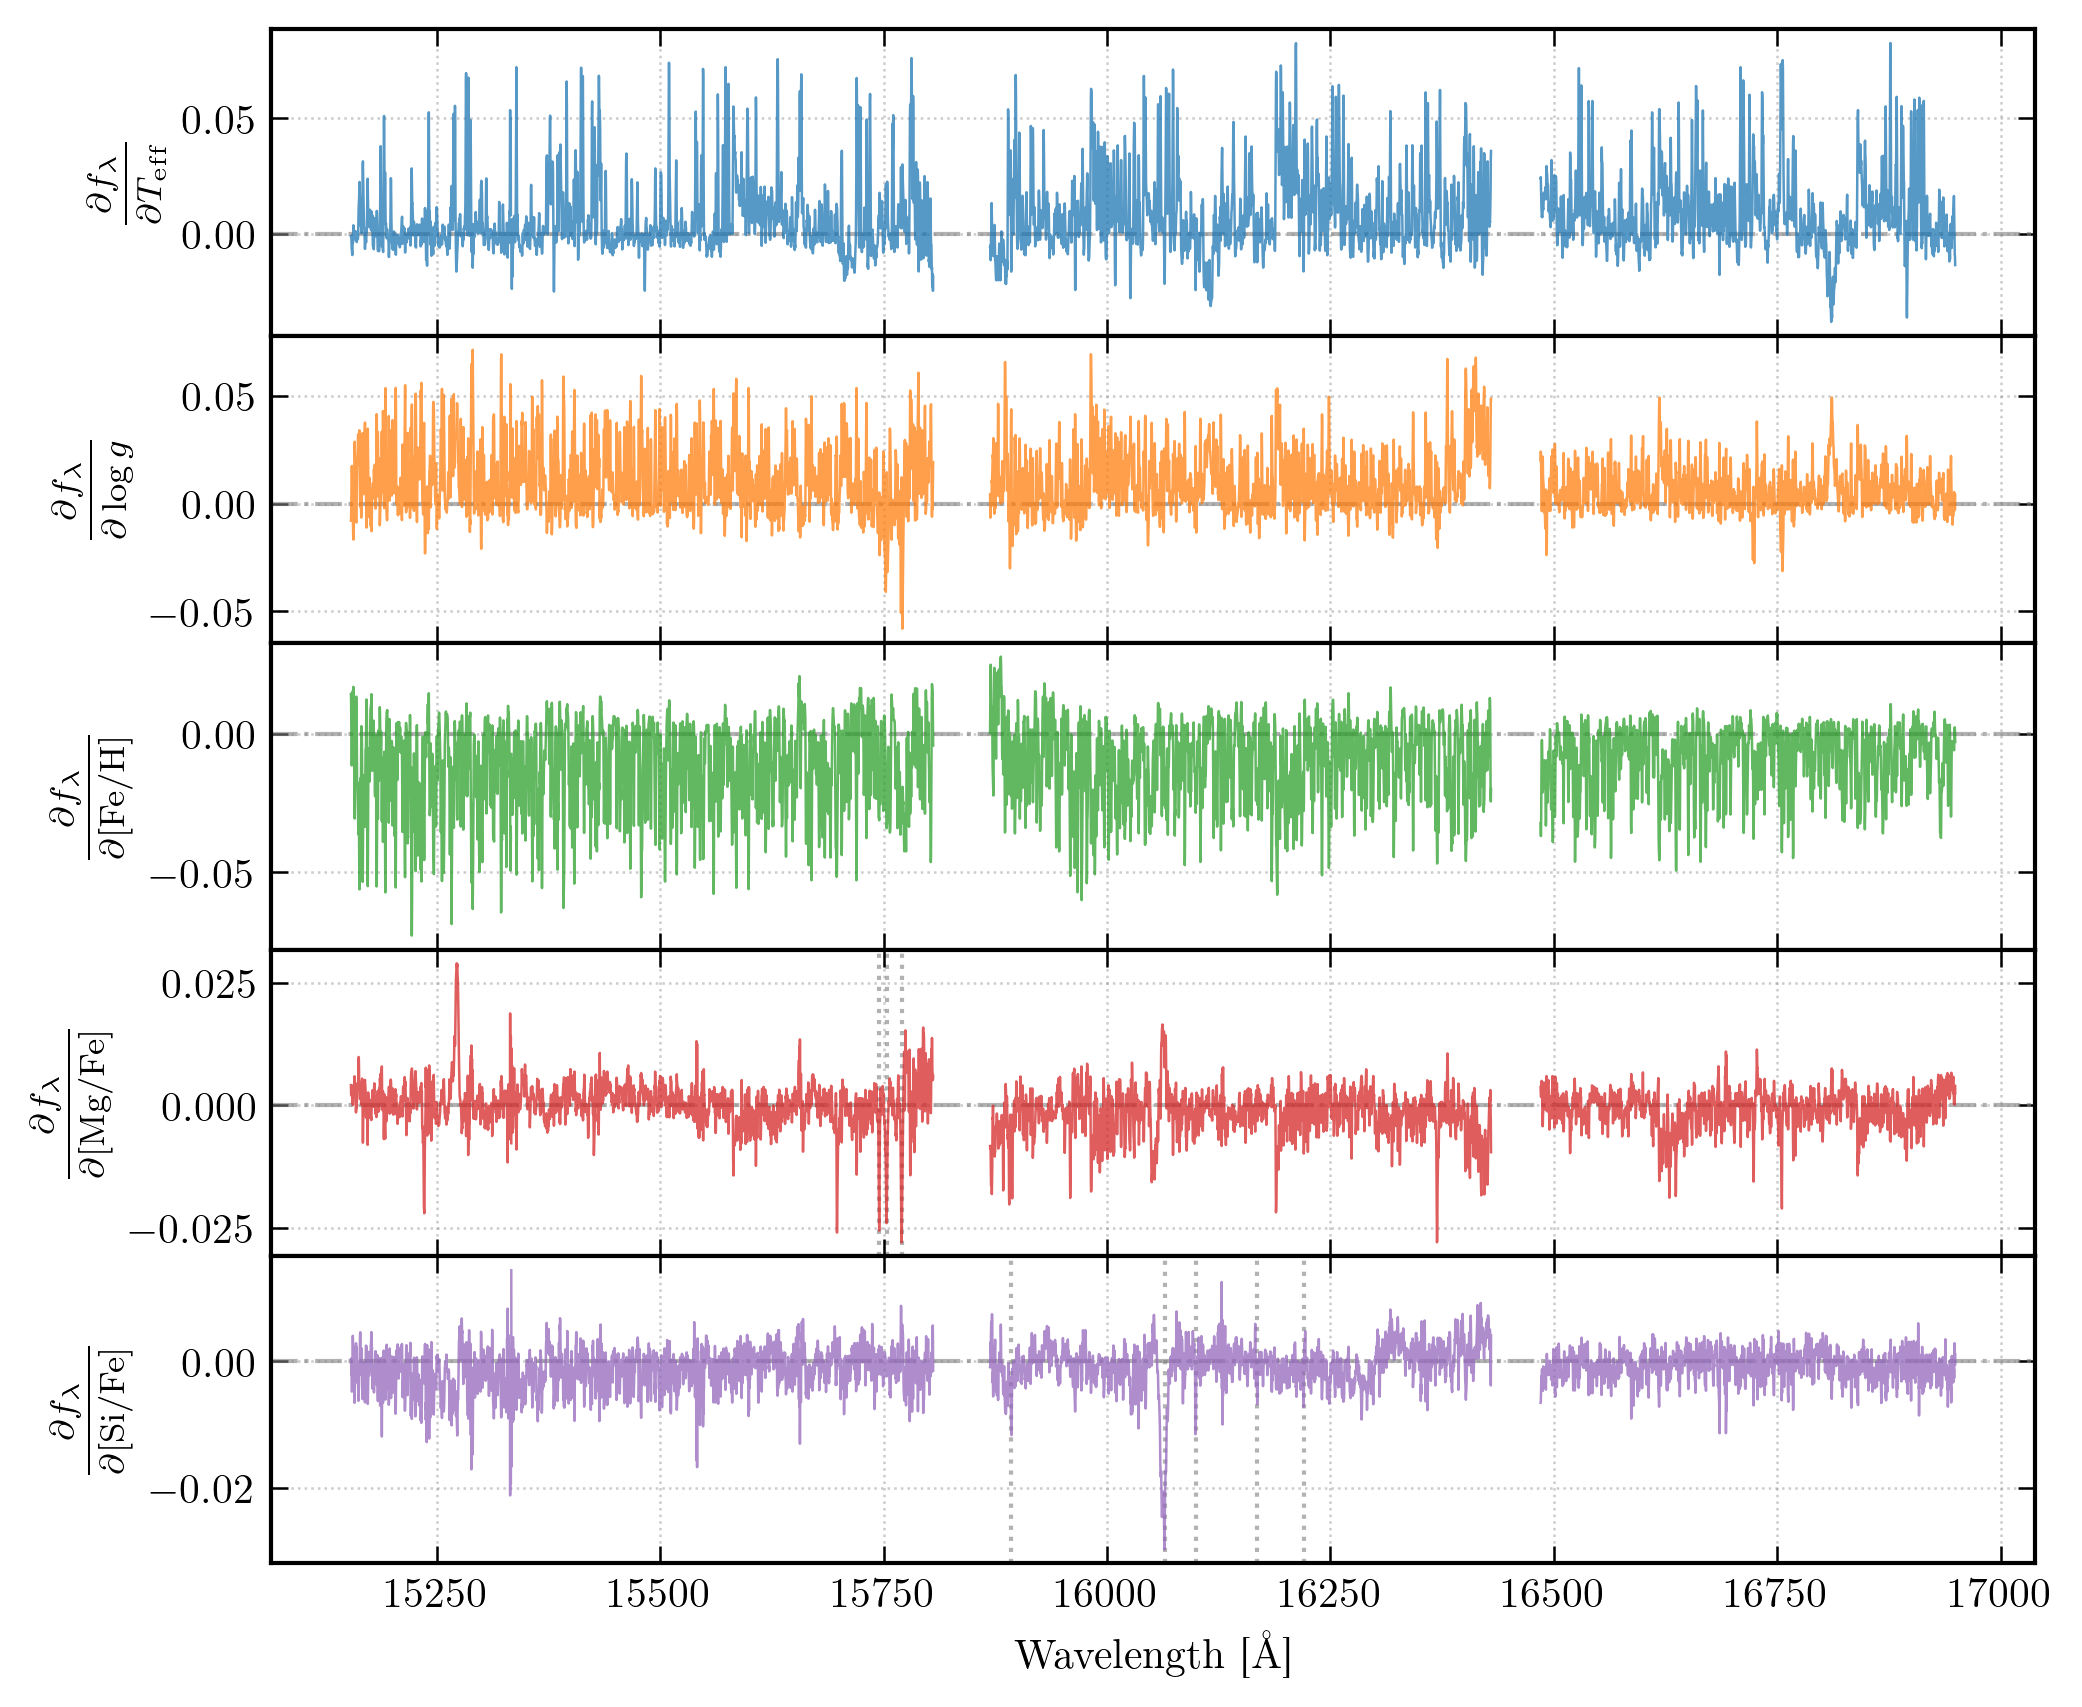

In [9]:
axes = plotters.plot_gradient_spectra(model)
plt.show()

### 8b — Scatter spectrum

The per-pixel intrinsic scatter $s_\lambda$ quantifies how much additional variance beyond measurement error is needed to explain the training data. High-scatter regions correspond to strong absorption lines where the 2nd-order polynomial model is insufficient — the true line profile dependence on labels is more complex than a quadratic can capture.

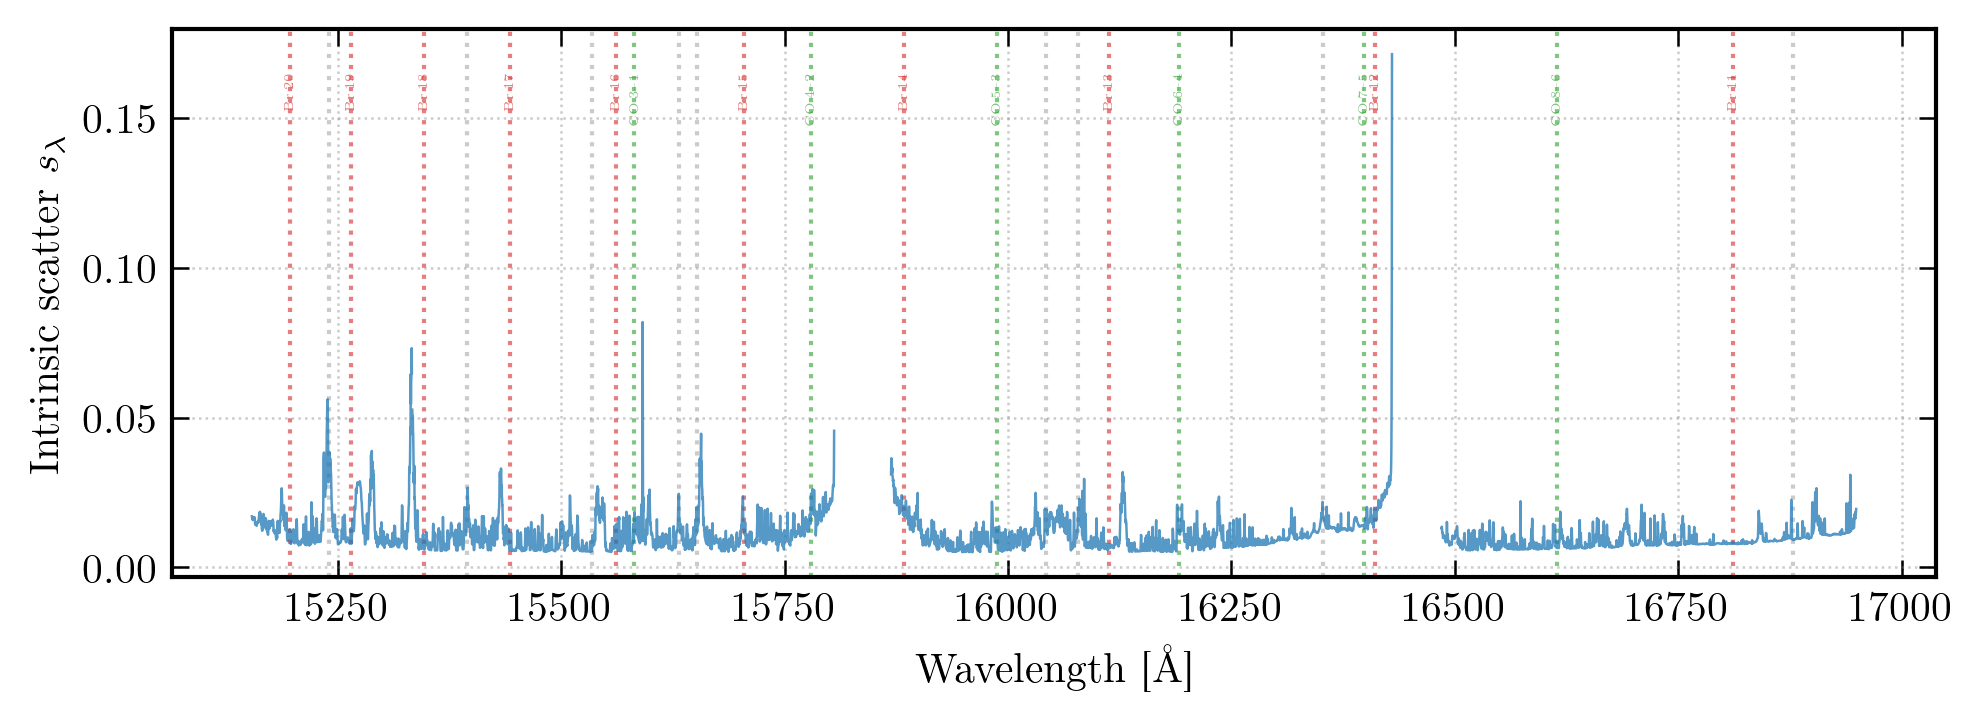

In [10]:
ax = plotters.plot_scatter_spectrum(model)
plt.show()

### Scatter spectrum analysis

The larger-than-average scatter regions fall into three categories:

**Genuine model inadequacy at strong absorption lines.** The 2nd-order polynomial cannot capture the nonlinear label dependence of deep spectral features. The dominant contributors are:

- **Brackett hydrogen series** (Br12–Br20, ~15196–16411 Å; NIST ASD): pressure-broadened lines whose profiles depend on $T_{\rm eff}$ and $\log g$ in a way that is poorly approximated by a quadratic. The broad wings blend with neighboring features, further complicating the polynomial fit.
- **CO first-overtone bandheads** (~15582, 15780, 16398 Å; Kleinmann & Hall 1986, Wallace & Hinkle 1997): molecular equilibrium is a steep function of $T_{\rm eff}$ — CO dissociates rapidly above ~4500 K, creating a near-discontinuous label dependence that no polynomial can follow.
- **Strong Fe I lines** (~15240, 15395, 15534, 15632, 15652, 16078, 16352, 16878 Å; Shetrone et al. 2015, Smith et al. 2021) and **Mg I** (15745, 15753, 15770 Å; NIST ASD), **Si I** (15893, 16064 Å; NIST ASD): saturated lines whose equivalent widths respond nonlinearly to abundance changes.

**Chip-edge artifacts.** The broad elevated region at ~15795–15882 Å coincides with the right edge of the blue chip, where few training stars contribute valid data.

 Although the valid-fraction cut removes the worst pixels, the transition zone retains marginal data quality that inflates the scatter. A similar but narrower feature appears near the green chip right edge (~16415–16480 Å).

**Unflagged single-star outliers.** A sharp spike at ~16574 Å is driven by one star (2M21290172+1332232) with a 2-pixel negative flux artifact ($f \approx -2$ on a normalized scale of $\sim 1$). The raw APOGEE coadded spectrum shows flux jumping from $+162$ to $-330$ and back within 2 pixels, with no bitmask bits set and a normal error of $\sim 3$. This is a cosmic ray or detector artifact that escaped the APOGEE pipeline's up-the-ramp rejection. Removing this single star would reduce the scatter at this wavelength from $s_\lambda = 0.099$ to $s_\lambda = 0.013$, consistent with the surrounding continuum. Similar isolated spikes at ~16939 Å likely have the same origin.

### Save trained model

In [11]:
np.savez_compressed(
    "cannon_model.npz",
    theta=model.theta,
    scatter=model.scatter,
    label_means=model.label_means,
    label_stds=model.label_stds,
    wavelength=model.wavelength,
    label_names=np.array(model.label_names),
    chi2_r=np.array(model.chi2_r),
    train_idx=train_idx,
    cv_idx=cv_idx,
)
print("Saved cannon_model.npz")
print(f"  theta: {model.theta.shape}")
print(f"  scatter: {model.scatter.shape}")
print(f"  chi2_r: {model.chi2_r:.3f}")
print(f"  train_idx: {train_idx.shape}")
print(f"  cv_idx: {cv_idx.shape}")

Saved cannon_model.npz
  theta: (8575, 21)
  scatter: (8575,)
  chi2_r: 0.998
  train_idx: (942,)
  cv_idx: (944,)
